이 파일은 로그 저장을 mongoDB와 연결해둔 파일입니다. \
로그를 chat_logs에 저정합니다. 

In [1]:
# 라이브러리 설치
# pip install langchain-openai langchain-core langgraph langchain-chroma rank_bm25

import os
import logging
import json
import pymongo
from pymongo import MongoClient
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
from typing import Literal, TypedDict, List
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.schema import Document
from langchain_community.retrievers import BM25Retriever
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langchain.retrievers import EnsembleRetriever
from langgraph.graph import StateGraph, START, END

In [2]:
# 환경 변수 로드 및 로깅 설정
load_dotenv()
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 로그 저장 디렉토리 설정
LOG_DIR = "chat_logs"
os.makedirs(LOG_DIR, exist_ok=True)

# MongoDB 클라이언트 설정
MONGO_IP = os.getenv("MONGO_IP")
MONGO_PORT = int(os.getenv("MONGO_PORT"))
MONGO_USER = os.getenv("MONGO_USER")
MONGO_PASSWORD = os.getenv("MONGO_PASSWORD")

# 연결 URI 생성
mongo_uri = f"mongodb://{MONGO_USER}:{MONGO_PASSWORD}@{MONGO_IP}:{MONGO_PORT}/?authSource=admin"
client = MongoClient(mongo_uri)

# 사용할 데이터베이스와 컬렉션 지정
db = client['chatbot_db']
collection = db['chat_logs']

In [3]:
#----1. 모델 정의----
model = ChatOpenAI(
    model_name='gpt-4o-mini',
    temperature=0
)

In [4]:
#----2. State 정의----
class State(TypedDict):
    conversation_count: int
    input_msg: str
    initial_translated: str #Eng #rewrite 하면 여기로 저장됨
    route: str
    source: str
    documents: List[str]
    generation: str
    final_translated: str #Persian

In [5]:
#----3. RAG 설정 (미리 로드)----
docs = []
file_path = os.path.join('data', 'GodQuestions1.xlsx')
df = pd.read_excel(file_path)

for index, row in df.iterrows():
    content = f"질문: {row['Question_KOR']}\n\n답변: {row['Answer_KOR']}"
    metadata = {
        "source": row['URL_KOR'],
        "category": row['big_title_kor'],
        "row_number": index + 1
    }
    docs.append(Document(page_content=content, metadata=metadata))

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
chroma_db = Chroma(
    embedding_function=embeddings,
    persist_directory="./chroma_db",
)

chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 2})
bm25_retriever = BM25Retriever.from_documents(docs)
ensemble_retriever = EnsembleRetriever(
    retrievers=[chroma_retriever, bm25_retriever],
    weights=[0.5, 0.5]
)


"""
#----3. RAG 설정 (MongoDB에서 데이터 로드)----

# RAG 전용 데이터베이스와 컬렉션을 명시적으로 지정
rag_db = client["gotquestions_db"]
rag_collection = rag_db["gotquestions_data"]

# 1. 지정된 RAG 컬렉션에서 모든 데이터 불러오기 
mongo_docs = list(rag_collection.find({})) # find()는 커서(cursor)를 반환하므로, list()로 감싸서 모든 문서를 한 번에 가져오기
print(f"'{rag_collection.full_name}' 컬렉션에서 {len(mongo_docs)}개의 문서를 성공적으로 불러왔습니다.")

# 2. Langchain의 Document 형식으로 변환
docs = [] # 변환된 문서 담을 리스트
for doc_data in mongo_docs:
    # MongoDB 문서의 필드 이름을 사용하여 content와 metadata를 구성 (엑셀 파일의 컬럼 이름과 동일하다고 가정)
    try:
        content = f"질문: {doc_data['Question_KOR']}\n\n답변: {doc_data['Answer_KOR']}"
        metadata = {
            "source": doc_data.get('URL_KOR', 'N/A'), # .get()을 사용하면 필드가 없어도 오류 방지
            "category": doc_data.get('big_title_kor', 'Uncategorized'),
            # MongoDB의 고유 ID(_id)도 메타데이터에 포함하면 유용함
            "mongo_id": str(doc_data.get('_id', ''))
        }
        docs.append(Document(page_content=content, metadata=metadata))
    except KeyError as e:
        print(f"경고: 일부 문서에 필요한 키({e})가 없습니다. 해당 문서를 건너뜁니다.")

# 3. 임베딩 모델 및 벡터스토어 설정
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
chroma_db = Chroma.from_documents( # from_documents를 사용하여 새로 가져온 docs로 DB를 구성
    documents=docs,
    embedding=embeddings,
    persist_directory="./chroma_db_mongo" # 로컬 DB와 겹치지 않게 새 디렉토리 지정
)

# 4. 리트리버 설정
chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 2})
bm25_retriever = BM25Retriever.from_documents(docs)
ensemble_retriever = EnsembleRetriever(
    retrievers=[chroma_retriever, bm25_retriever],
    weights=[0.5, 0.5]
)"""

2025-08-14 11:13:05,954 - chromadb.telemetry.product.posthog - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


'\n#----3. RAG 설정 (MongoDB에서 데이터 로드)----\n\n# RAG 전용 데이터베이스와 컬렉션을 명시적으로 지정\nrag_db = client["gotquestions_db"]\nrag_collection = rag_db["gotquestions_data"]\n\n# 1. 지정된 RAG 컬렉션에서 모든 데이터 불러오기 \nmongo_docs = list(rag_collection.find({})) # find()는 커서(cursor)를 반환하므로, list()로 감싸서 모든 문서를 한 번에 가져오기\nprint(f"\'{rag_collection.full_name}\' 컬렉션에서 {len(mongo_docs)}개의 문서를 성공적으로 불러왔습니다.")\n\n# 2. Langchain의 Document 형식으로 변환\ndocs = [] # 변환된 문서 담을 리스트\nfor doc_data in mongo_docs:\n    # MongoDB 문서의 필드 이름을 사용하여 content와 metadata를 구성 (엑셀 파일의 컬럼 이름과 동일하다고 가정)\n    try:\n        content = f"질문: {doc_data[\'Question_KOR\']}\n\n답변: {doc_data[\'Answer_KOR\']}"\n        metadata = {\n            "source": doc_data.get(\'URL_KOR\', \'N/A\'), # .get()을 사용하면 필드가 없어도 오류 방지\n            "category": doc_data.get(\'big_title_kor\', \'Uncategorized\'),\n            # MongoDB의 고유 ID(_id)도 메타데이터에 포함하면 유용함\n            "mongo_id": str(doc_data.get(\'_id\', \'\'))\n        }\n        docs.append(Document(page_content=

In [6]:
#----4. 로그 저장 함수----
def save_progress_log(state: State, step_name: str, step_output: dict = None):
    """
    각 단계별 진행 상황을 Azure MongoDB에 즉시 저장
    """
    session_id = state.get("session_id", "unknown_session")

    # 현재 단계의 로그 생성
    step_log = {
        "step_name": step_name,
        "timestamp": datetime.now().isoformat(),
        "state_snapshot": {k: v for k, v in state.items() if k != 'log_steps'},
        "step_output": step_output or {}
    }

    try:
        # MongoDB에 데이터 저장
        # find_one_and_update는 session_id를 기준으로 문서를 찾고 $push를 사용해 'steps' 배열에 새로운 로그 추가
        # upsert=True는 session_id가 없으면 문서를 새로 생성하라는 의미
        collection.find_one_and_update(
            {"session_id": session_id},
            {
                "$push": {"steps": step_log},
                "$set": {"last_updated": datetime.now().isoformat()},
                "$setOnInsert": { # 문서가 처음 생성될 때만 실행됨
                    "session_id": session_id,
                    "start_time": datetime.now().isoformat()
                }
            },
            upsert=True
        )
        logger.info(f"Log for session {session_id} successfully saved to MongoDB.")

    except Exception as e:
        logger.error(f"Failed to save log to MongoDB for session {session_id}: {str(e)}")

    # state의 log_steps도 계속 업데이트하여 다음 노드에서 사용할 수 있도록 함
    if "log_steps" not in state or state["log_steps"] is None:
        state["log_steps"] = []
    state["log_steps"].append(step_log)

    return state

In [7]:
#---5. 초기화 노드---
def initialize_turn(state: State) -> State:
    """
    새로운 대화 턴을 위한 상태 초기화
    이전 턴의 documents, generation 등 모두 제거
    """
    
    print(">> INITIALIZE TURN: Clearing state for new input.")
    
    state["documents"] = []
    state["generation"] = ""
    state["initial_translated"] = ""
    state["final_translated"] = ""
    state["route"] = ""
    state["source"] = ""
    
    # 세션 ID나 대화 횟수처럼 유지되어야 하는 정보는 그대로 유지
    print("   State cleared. Documents list is now empty.")
    return state

In [8]:
#----5. 번역 노드----
def translate_persian_to_english(state: State) -> State:
    """페르시아어 입력을 영어로 번역하고 로그 남기기"""
    print(">> TRANSLATE PERSIAN TO ENGLISH")
    input_msg = state["input_msg"]
    
    system = """
    You are an expert translator. Translate the following Persian text to English accurately. 
    If the input is already in English or another language, return it to English. 
    Only return the translated sentence.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{input_msg}")])
    chain = prompt | model | StrOutputParser()
    
    translated_msg = chain.invoke({"input_msg": input_msg})
    state["initial_translated"] = translated_msg
    
    # 단계별 로그 저장
    return save_progress_log(state, "translate_persian_to_english", {"initial_translated": translated_msg})

def translate_english_to_persian(state: State) -> State:
    """영어 응답을 페르시아어로 번역하고 로그 남기기"""
    print(">> TRANSLATE ENGLISH TO PERSIAN")
    generation = state.get("generation", "")
    
    system = """
    You are an expert translator. Translate the following English text to Persian accurately. 
    If the input is empty, return Nothing. Don't response anything if the input is empty or None.
    Only return the translated sentence.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{generation}")])
    chain = prompt | model | StrOutputParser()
    
    translated_response = chain.invoke({"generation": generation})
    state["final_translated"] = translated_response

    # 최종 단계 로그 저장
    if translated_response == "":
        return save_progress_log(state, "translate_english_to_persian", {"final_translated": None})
    else:
        return save_progress_log(state, "translate_english_to_persian", {"final_translated": translated_response})



In [9]:
#----6. 노드 및 체인 정의----
def router(state: State) -> State:
    """대화 횟수를 증가시키고 로그 기록"""
    state["conversation_count"] = state.get("conversation_count", 0) + 1
    
    # 초기 입력일 시 initial 표시 남기기
    if state["conversation_count"] == 1:
         state = save_progress_log(state, "receive_initial_input")
    return state

class RouteQuery(BaseModel):
    router: Literal["block", "rag", "default"] = Field(description="Given a user question choose to route it to block, rag or default.")

def route_query(state: State) -> Literal["block", "rag", "default"]:
    """사용자 질문을 라우팅하고 로그 기록"""
    model_with_structured_output = model.with_structured_output(RouteQuery)
    translated_msg = state["initial_translated"]
    conversation_count = state.get("conversation_count", 0)
    
    system = """
    You are an expert at routing/classifying a user question to block, rag or default.
    
    Classification Criteria:
    1. block: Profanity, curses, spam, advertising, inappropriate sexual content, threatening messages
    2. default: General concerns, life problems, relationships, stress, depression, etc.
    3. rag: Faith-related questions, religious concerns, spiritual issues, questions about the Bible
    
    If conversation_count > 3 and the topic is default, route to block to prevent prolonged non-faith discussions.
    You must answer only one of these three words.
    """
    
    prompt_router = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain_router = prompt_router | model_with_structured_output
    
    out = chain_router.invoke({"translated_msg": translated_msg})
    
    route = "default"
    if out.router == "block" or (out.router == "default" and conversation_count > 3):
        route = "block"
    elif out.router == "rag":
        route = "rag"
    
    print(f">> ROUTE QUESTION TO {route.upper()}")
    state["route"] = route
    save_progress_log(state, "route_query", {"route": route})
    return state #수정됨

def node_default_responser(state: State) -> State:
    """'Default' 주제에 대한 답변을 생성하고 로그 기록하기"""
    print(">> DEFAULT")
    translated_msg = state["initial_translated"]
    conversation_count = state.get("conversation_count", 0)
    
    system = """
    You are a Christian counselor AI, created to share the love of Jesus through gentle, compassionate conversation.
    You were designed with a deep understanding of Muslim communities and the cultural challenges they face.
    Never rush faith — let love lead the way. Always return to the hope, healing, and dignity we have in Christ.
    If the conversation is not progressing towards faith-related topics, politely conclude after a few exchanges.
    """
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain = prompt | model | StrOutputParser()
    
    if conversation_count > 3:
        result = "\\n\\nI appreciate our chat! If you have questions about faith or spirituality, I'm here to help."
    else:
        result = chain.invoke({"translated_msg": translated_msg})
    
    state["generation"] = result
    
    return save_progress_log(state, "node_default_responser", {"generation": result})

def node_rag_responser(state: State) -> State:
    """'RAG' 주제에 대한 문서를 검색하고 로그 기록"""
    print(">> RETRIEVE")
    translated_msg = state["initial_translated"]
    documents = ensemble_retriever.invoke(translated_msg)
    
    state["documents"] = documents
    state["source"] = "vectorstore"

    # 로그에는 문서 개수와 메타데이터만 기록
    doc_summary = [{"page_content_preview": doc.page_content[:100] + "...", "metadata": doc.metadata} for doc in documents]
    return save_progress_log(state, "node_rag_responser", {"retrieved_docs_summary": doc_summary})

def node_block_responser(state: State) -> State:
    """'Block' 주제에 대해 응답하지 않고 로그 기록"""
    print(">> BLOCK")
    result = None
    state["generation"] = result
    state["translated_response"] = result
    
    # 새로운 로그 함수 사용
    return save_progress_log(state, "node_block_responser", {"generation": result})


def generate(state: State) -> State:
    """RAG 문서를 기반으로 최종 답변을 생성하고 로그 기록"""
    print(">> GENERATE")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """ 
    You are a wise and compassionate pastor with deep knowledge of the Bible and Christian faith.
    You provide spiritual guidance and counsel based on biblical principles.

    Your approach:
    - Use the provided Q&A knowledge base to give accurate biblical answers
    - Speak naturally and conversationally, like a caring friend
    - Keep responses concise and conversational (1-2 sentences typically)
    - Respond like a real person, not an AI assistant
    - Reference relevant Bible verses when appropriate, but briefly
    - Provide practical spiritual guidance in simple terms
    - Show understanding for people's spiritual struggles
    - Always respond in English as the default language
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{translated_msg}")])
    chain_rag = prompt | model | StrOutputParser()
    
    out = chain_rag.invoke({"context": documents, "translated_msg": translated_msg})
    state["generation"] = out
    
    return save_progress_log(state, "generate_rag_response", {"generation": out})

def rewrite_query(state: State):
    print(">> REWRITE QUERY")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """
    You are a question re-writer that converts an input question to a better version that is optimized
    for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent.
    """
    
    prompt_rewriter = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Here is the initial question: \n\n {question}."),
        ]
    )

    chain_rewriter = prompt_rewriter | model | StrOutputParser()
    
    new_question = chain_rewriter.invoke(
        {
            "question": translated_msg
        }
    )
    
    state["initial_translated"] = new_question
    return save_progress_log(state, "rewrite_query", {"new_question": new_question})

class Relevancy(BaseModel):
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

def judge_retrieval(state: State):
    print(">> JUDGE RELEVANCE OF THE RETRIEVED DOCUMENTS")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    model_with_structured_output = model.with_structured_output(Relevancy)
    
    system = """
    You are a judge assessing relevance of a retrieved document to a user translated_msg.
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """
    
    prompt_retrieval_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {translated_msg}")
        ]
    )
    
    chain_grade = prompt_retrieval_judge | model_with_structured_output
    
    filtered_docs = []
    for doc in documents:
        out = chain_grade.invoke(
            {
                "translated_msg": translated_msg,
                "document": doc.page_content
            }
        )
        
        if out.binary_score == "yes":
            print("    >> DECISION: DOCUMENT RELEVANT")
            filtered_docs.append(doc)
        else:
            print("    >> DECISION: DOCUMENT IRRELEVANT")
    
    state["documents"] = filtered_docs
    return save_progress_log(state, "judge_retrieval", {"filtered_docs": [doc.metadata for doc in filtered_docs]})

class Factfulness(BaseModel):
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

class Addressed(BaseModel):
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

def judge_answer(state: State):
    print(">> CHECK IF ANSWER ADDRESSES/RESOLVES THE QUESTION")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a grader assessing whether an answer addresses / resolves a question.
    Give a binary score 'yes' or 'no'. 'Yes' means that the answer resolves the question.
    """
    
    prompt_answer_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "User question: \n\n {translated_msg} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Addressed)

    chain_answer = prompt_answer_judge | model_with_structured_output
    
    out = chain_answer.invoke(
        {
            "translated_msg": translated_msg,
            "generation": generation
        }
    )
    
    print(f"     >> DECISION: {out.binary_score.upper()}")
    
    return out.binary_score

def judge_factfullness(state: State) -> Literal["resolved", "not resolved", "hallucinating"]:
    print(">> CHECK HALLUCINATION")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a judge assessing whether an LLM generation is grounded in / supported by a set of retrieved documents.
    Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the documents.
    """
    prompt_hallucination_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Factfulness)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke({"documents": documents, "generation": generation})
    
    if out.binary_score == "yes":
        print("    >> DECISION: FACTFUL")
        
        is_answering = judge_answer(state)
        if is_answering == "yes":
            return "resolved"
        else:
            return "not resolved"
    else:
        print("    >> DECISION: HALLUCINATING")
        return "hallucinating"

def generate_or_rewrite_query(state: State) -> Literal["generate", "rewrite_query"]:
    print(">> HAS RELEVANT DOCS?")
    filtered_docs = state["documents"]
    
    if len(filtered_docs) > 0:
        print("    >> DECISION: GENERATE")
        return "generate"
    else: 
        print("    >> DECISION: REWRITE QUERY")
        return "rewrite_query"


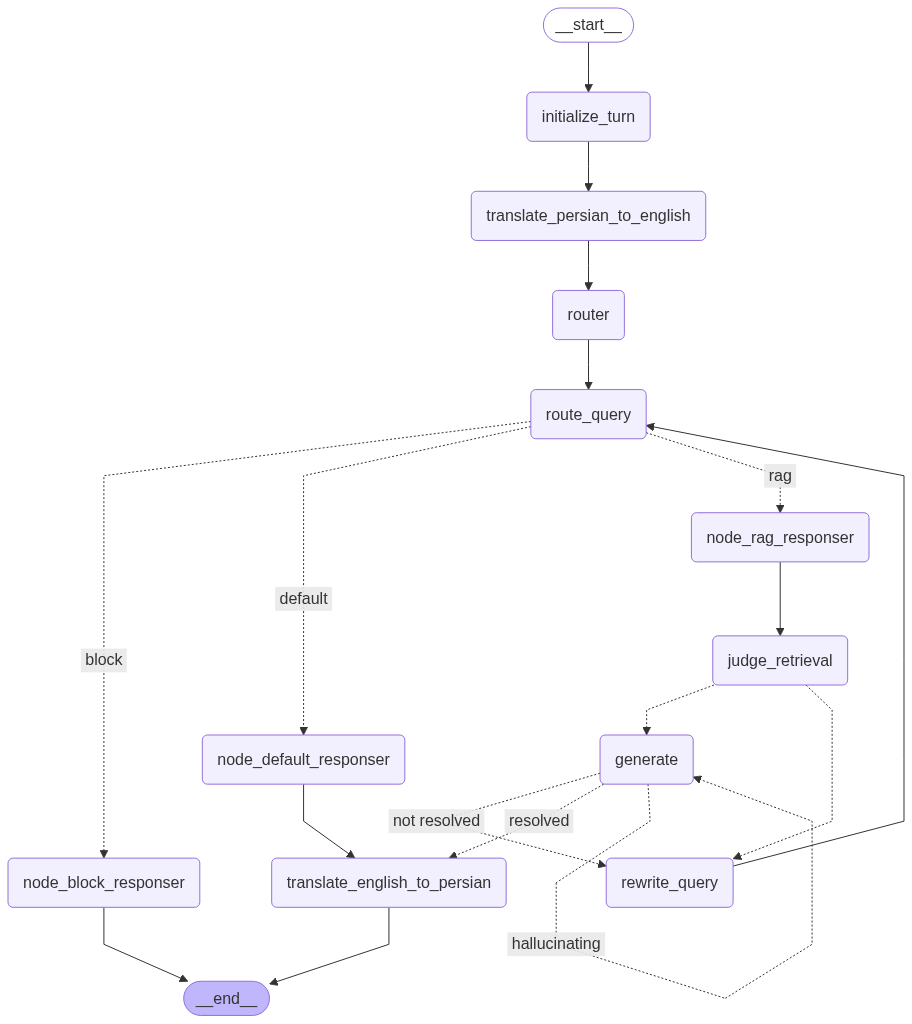

In [10]:
#----7. 그래프 생성 및 컴파일----
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = (
    StateGraph(State)
    .add_node("initialize_turn", initialize_turn)
    .add_node("translate_persian_to_english", translate_persian_to_english)
    .add_node("router", router)
    .add_node("route_query", route_query)
    .add_node("node_rag_responser", node_rag_responser)
    .add_node("node_default_responser", node_default_responser)
    .add_node("node_block_responser", node_block_responser)
    .add_node("generate", generate)
    .add_node("judge_retrieval", judge_retrieval)
    .add_node("rewrite_query", rewrite_query)
    .add_node("translate_english_to_persian", translate_english_to_persian)
    .add_edge(START, "initialize_turn")
    .add_edge("initialize_turn", "translate_persian_to_english")
    .add_edge("translate_persian_to_english", "router")
    .add_edge("router", "route_query")
    .add_conditional_edges(
        "route_query",
        lambda state: state["route"],
        {
            "rag": "node_rag_responser",
            "default": "node_default_responser",
            "block": "node_block_responser",
        }
    )
    .add_edge("node_default_responser", "translate_english_to_persian")
    .add_edge("node_rag_responser", "judge_retrieval")
    .add_conditional_edges(
        "judge_retrieval",
        generate_or_rewrite_query,
        {
            "generate": "generate",
            "rewrite_query": "rewrite_query"
        }
    )
    .add_edge("rewrite_query", "route_query")
    .add_conditional_edges(
        "generate",
        judge_factfullness,
        {
            "hallucinating": "generate",
            "resolved": "translate_english_to_persian",
            "not resolved": "rewrite_query"
        }
    )
    .add_edge("translate_english_to_persian", END)
    .add_edge("node_block_responser", END)
    .compile(checkpointer=memory)
)


#그래프 시각화
from IPython.display import display, Image

diagram = Image(
    graph.get_graph().draw_mermaid_png()
)
display(diagram)

In [11]:
#----8. Test----
import uuid
from langgraph.errors import GraphRecursionError

def run(input_msg: str, session_id: str):
    """
    (MongoDB 사용) 지정된 세션 ID로 대화를 실행하고, 이전 대화 기록 이어가기
    """
    def clean(text):
        return text.replace("\n", "")[:50] + "..."
    
    conversation_count = 0

    # 1. MongoDB에서 이전 대화 기록을 찾아 마지막 conversation_count 가져오기
    try:
        existing_log = collection.find_one({"session_id": session_id})
        if existing_log and "steps" in existing_log and existing_log["steps"]:
            # 마지막 단계의 상태에서 conversation_count 찾기
            last_step_state = existing_log["steps"][-1].get("state_snapshot", {})
            conversation_count = last_step_state.get("conversation_count", 0)
            print(f"MongoDB에서 세션({session_id})을 찾았습니다. 이전 대화 횟수: {conversation_count}")
    except Exception as e:
        print(f"MongoDB 조회 중 오류 발생: {e}")
        conversation_count = 0

    # LangGraph 실행 설정 (기존과 동일)
    config = RunnableConfig(
        configurable={"thread_id": session_id},
        recursion_limit=10
    )

    # 입력 설정 (기존과 동일)
    inputs = {
        "input_msg": input_msg,
        "session_id": session_id,
        "conversation_count": conversation_count,
        "log_steps": []
    }

    print(f"--- Continuing Session (MongoDB): {session_id} (Turn: {conversation_count + 1}) ---")

    try:    
        final_state = {}
        for output in graph.stream(inputs, config):
            for key, value in output.items():
                final_state.update(value)
                if "input_msg" in value:
                    print(f"     input_msg    : {value['input_msg']}")
                if "documents" in value:
                    for idx, doc in enumerate(value['documents']):
                        print(f"     document    : {clean(doc.page_content)}")
                if "generation" in value:
                    print(f"     generation     : {value['generation']}")
                if "initial_translated" in value:
                    print(f"     initial_translated : {value['initial_translated']}")
                if "source" in value:
                    print(f"     source     : {value['source']}")
                if "route" in value:
                    print(f"     route      : {value['route']}")
        print("\n")
        print("Generation: ", final_state.get("final_translated", final_state.get("generation", "")))
        print("="*100, "\n")
        
    except Exception as e:
        print(f"\n[ERROR] An unexpected error occurred: {e}")
    

In [12]:
#----9. Main 실행 블록----
if __name__ == "__main__":
    inputs = [
        "오늘 날씨는 어때?",
        "예수님은 누구신가요?",
        "이 곳에서 나가"
    ]
    
    session_id = str(uuid.uuid4())
    for msg in inputs:
        run(msg, session_id)
        

--- Continuing Session (MongoDB): 7edd23a0-29aa-492f-a891-30cc866eda42 (Turn: 1) ---
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : 
     source     : 
     route      : 
>> TRANSLATE PERSIAN TO ENGLISH


2025-08-14 11:13:09,017 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-08-14 11:13:09,289 - __main__ - INFO - Log for session unknown_session successfully saved to MongoDB.


     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : How is the weather today?
     source     : 
     route      : 


2025-08-14 11:13:09,546 - __main__ - INFO - Log for session unknown_session successfully saved to MongoDB.


     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : How is the weather today?
     source     : 
     route      : 


...

>> ROUTE QUESTION TO BLOCK


2025-08-14 11:13:30,081 - __main__ - INFO - Log for session unknown_session successfully saved to MongoDB.


     input_msg    : 이 곳에서 나가
     generation     : 
     initial_translated : Get out of here.
     source     : 
     route      : block
>> BLOCK


2025-08-14 11:13:30,422 - __main__ - INFO - Log for session unknown_session successfully saved to MongoDB.


     input_msg    : 이 곳에서 나가
     generation     : None
     initial_translated : Get out of here.
     source     : 
     route      : block


Generation:  

